<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis: Welltory COVID-19 and Wearables Open Data Research

##### Hasan Al-Quaid

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load in welltory git repo
!git clone https://github.com/Welltory/hrv-covid19.git

fatal: destination path 'hrv-covid19' already exists and is not an empty directory.


In [3]:
%matplotlib inline

##### Will use the participants.csv
- I am intrested in knowing the type of people Covid has affected, and the participants.csv looks like it has all the data i need.
- It also looks to be mostly filled out, and most of the data looks promising. 
- As well as giving us the ability to see all the raw number of participants, most files seems like they have multiple row enteries per user code
- This file will give me a good starting point and enough useful info for this assignment.

In [4]:
participants_df = pd.read_csv("hrv-covid19/data/participants.csv")

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [5]:
# Data Structure
# Dimensions of the dataset(number of rows and columns)
print("Data Structure")
print("---------------")
print(f"Dimensions of participants_df: {participants_df.shape}")

Data Structure
---------------
Dimensions of participants_df: (185, 8)


In [6]:
# Data types of the variables (numerical, categorical, text, etc.):
print(f"Data Types of participants_df :\n{participants_df.dtypes}")

Data Types of participants_df :
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object


In [7]:
# Are there any missing values, and if so, how are they represented?
print(f"Missing Values for participants_df:\n{participants_df.isnull().sum()}")

Missing Values for participants_df:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


## Interpretation

The first dataframe indicates that there are 185 people, with 8 columns that tell us information about the participants. The participants df looks to be missing some information regarding city, country, height, weight, and symptoms onset. 

The dataset is incomplete, and further cleaning will be needed to clean the dataset before use. 

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [8]:
# Descriptive Statistics for participants_df
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = participants_df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(participants_df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(participants_df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(participants_df[numeric_columns].skew())
print(participants_df[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
          height     weight
mean  169.976393  77.927757
50%   168.000000  74.344000

Dispersion Measures:
         height      weight
std   12.400103   19.552541
min  132.080000   43.500000
max  250.000000  154.221000

Distribution Measures:
------------------------
height    2.910275
weight    0.865345
dtype: float64
height    17.552808
weight     0.891368
dtype: float64


## Interpretation of participants df

#### Descriptive Statistics
The mean and median for both columns are fairly close, with `weight` (77.9 vs. 74.3) showing a slightly larger gap than `height` (170.0 vs. 168.0), suggesting a mild right skew in both, more so for weight.

#### Dispersion Measures
Both variables show reasonable spread relative to their means

#### Distribution Measures
`height` stands out with a notably high skewness (2.91) and a very high kurtosis (17.55), meaning it's more heavily right skewed, might suggest something wrong with the data.

## Questions we are asking:
* How are we handeling the missing values?
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [9]:
# Missing values (as shown above)
print(f"Missing Values for participants_df:\n{participants_df.isnull().sum()}")

Missing Values for participants_df:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


In [10]:
missing_counts = participants_df.isnull().sum()
total_rows = len(participants_df)
missing_percent = (missing_counts / total_rows) * 100

print(missing_percent.round(2))

user_code          0.00
gender             0.00
age_range          0.00
city               6.49
country            3.24
height             1.08
weight             0.00
symptoms_onset    20.54
dtype: float64



#### Missing values Analysis
* For `country`, `city`, and `height`, they are seem to be MCAR from looking at the excel sheet myself. I could either drop these rows or fill with a placeholder like "Unknown". I will choose the latter for country and city. But for height, I could fill the missing two values with mean, median, or mode.

* For `symptoms_onset`, we do have a large data that is missing, but looking at the data/column, this data is not useful for me. But, it could be MAR, or MNAR. But, since this data is not useful to me, I will simply not use/remove the column.


In [11]:
# Fill country/city with placeholder
participants_df['country'] = participants_df['country'].fillna('Unknown')
participants_df['city'] = participants_df['city'].fillna('Unknown')

# Fill height with median
participants_df['height'] = participants_df['height'].fillna(participants_df['height'].median())

# Drop symptoms_onset column 
participants_df = participants_df.drop(columns=['symptoms_onset'])

# Show all missign values are gone
print(participants_df.isnull().sum())

user_code    0
gender       0
age_range    0
city         0
country      0
height       0
weight       0
dtype: int64


In [12]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {participants_df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(participants_df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
          most_frequent_value
user_code          007b8190cf
gender                      f
age_range               35-44
city                   Moscow
country                Russia
height                  168.0
weight                   60.0


In [13]:
# Check if user_code is actually unique per row, output confirms each are unique, and the 007b8190cf, being the most consistent is false
print(participants_df['user_code'].nunique())
print(len(participants_df))

185
185


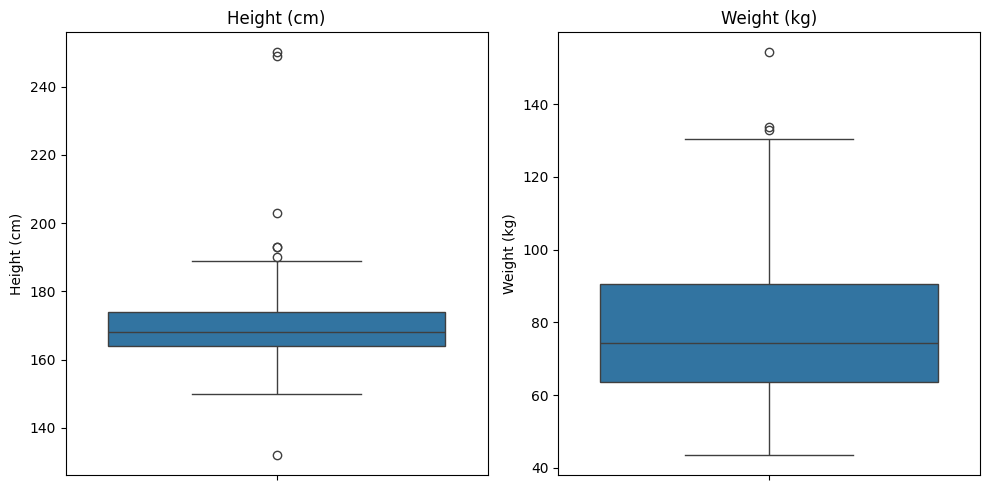

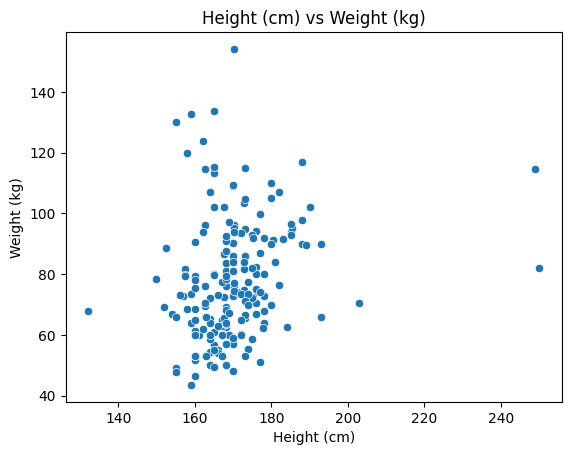

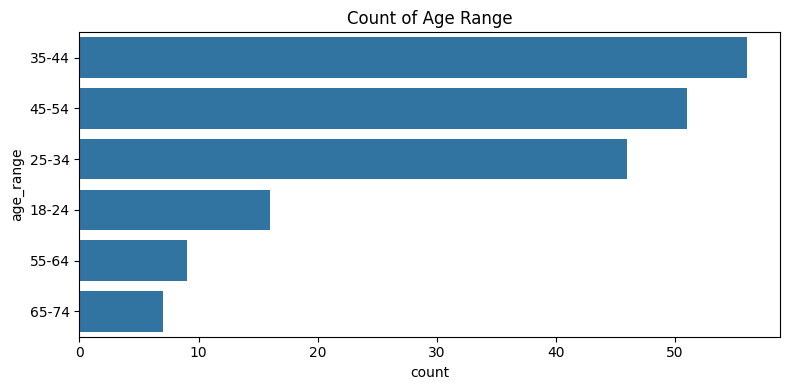

In [14]:
# Checking for outliers or extreme values 
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y=participants_df['height'], ax=axes[0])
axes[0].set_title('Height (cm)')
axes[0].set_ylabel('Height (cm)')
sns.boxplot(y=participants_df['weight'], ax=axes[1])
axes[1].set_title('Weight (kg)')
axes[1].set_ylabel('Weight (kg)')
plt.tight_layout()
plt.show()

# Scatterplot (height cm vs weight kg)
sns.scatterplot(data=participants_df, x='height', y='weight')
plt.title('Height (cm) vs Weight (kg)')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# Age Range
plt.figure(figsize=(8, 4))
sns.countplot(data=participants_df, y='age_range', order=participants_df['age_range'].value_counts().index)
plt.title('Count of Age Range')
plt.tight_layout()
plt.show()

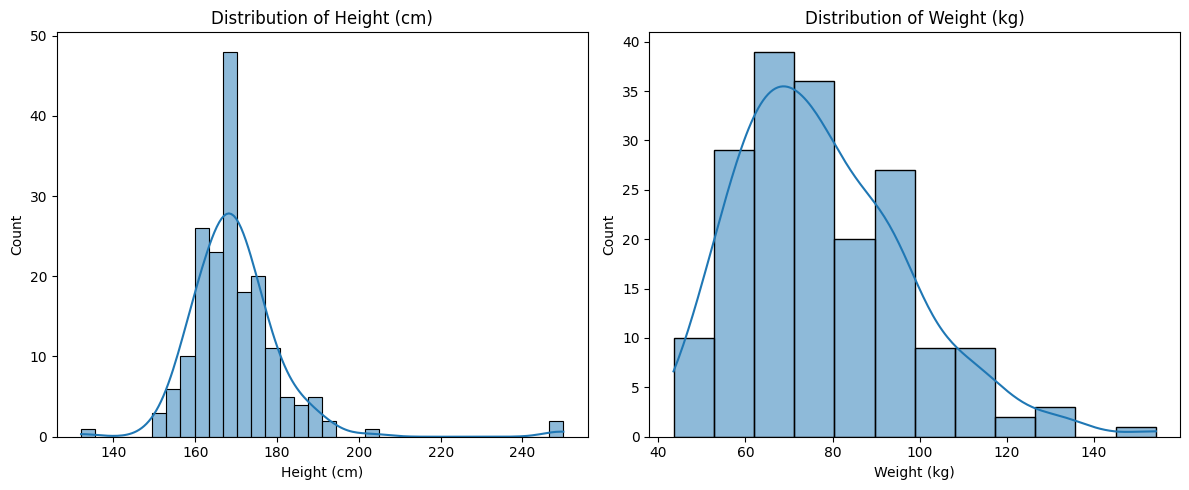

In [15]:
# Histograms for Height and Weight
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(participants_df['height'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Height (cm)')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Count')

sns.histplot(participants_df['weight'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Weight (kg)')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [16]:
def cm_to_feet_inches(cm):
    total_inches = cm / 2.54
    feet = int(total_inches // 12)
    inches = round(total_inches % 12, 1)
    return f"{feet}'{inches}\""

def kg_to_lbs(kg):
    return round(kg * 2.20462, 1)

def check_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- {column} ---")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")
    
    outliers_display = outliers[[column]].copy()
    
    if column == 'height':
        outliers_display['height_ft_in'] = outliers_display[column].apply(cm_to_feet_inches)
    elif column == 'weight':
        outliers_display['weight_lbs'] = outliers_display[column].apply(kg_to_lbs)
    
    print(outliers_display)
    print()

check_outliers_iqr(participants_df, 'height')
check_outliers_iqr(participants_df, 'weight')

--- height ---
Q1: 164.0, Q3: 174.0, IQR: 10.0
Lower bound: 149.0, Upper bound: 189.0
Number of outliers: 7
     height height_ft_in
49   248.92       8'2.0"
65   132.08       4'4.0"
83   203.00       6'7.9"
102  250.00       8'2.4"
112  190.00       6'2.8"
136  193.00       6'4.0"
175  193.00       6'4.0"

--- weight ---
Q1: 63.5, Q3: 90.537, IQR: 27.037000000000006
Lower bound: 22.94449999999999, Upper bound: 131.09250000000003
Number of outliers: 3
      weight  weight_lbs
24   132.900       293.0
109  133.810       295.0
137  154.221       340.0



In [17]:
# --- height ---
# Q1: 164.0, Q3: 174.0, IQR: 10.0
# Lower bound: 149.0, Upper bound: 189.0
# Number of outliers: 7
#      height height_ft_in
# 49   248.92       8'2.0"
# 65   132.08       4'4.0"
# 83   203.00       6'7.9"
# 102  250.00       8'2.4"
# 112  190.00       6'2.8"
# 136  193.00       6'4.0"
# 175  193.00       6'4.0"

# Analyzing the outliers for the Height:
# 49, 83, 102 look skepitical to me
height_outlier_indices = [49, 65, 83, 102, 112, 136, 175]
participants_df.loc[height_outlier_indices]

,user_code,gender,age_range,city,country,height,weight
49,3fff7627ca,m,35-44,Fountain Hill,United States,248.92,114.713
65,5214210ed1,f,45-54,Sacramento,United States,132.08,67.903
83,6ce06ce747,m,35-44,St Petersburg,Russia,203.00,70.534
102,83161408c1,m,25-34,Kurdistan,Iraq,250.00,82.146
112,985cf692d0,m,35-44,Kyiv,Ukraine,190.00,102.000
136,b3c7f65a4b,m,18-24,Bullard,United States,193.00,65.998
175,f8b552df37,m,45-54,Moscow,Russia,193.00,90.000


In [18]:
# --- weight ---
# Q1: 63.5, Q3: 90.537, IQR: 27.037000000000006
# Lower bound: 22.94449999999999, Upper bound: 131.09250000000003
# Number of outliers: 3
#       weight  weight_lbs
# 24   132.900       293.0
# 109  133.810       295.0
# 137  154.221       340.0


# Analyzing the outliers for the Weight:
weight_outlier_indices = [24, 109, 137]
participants_df.loc[weight_outlier_indices]

,user_code,gender,age_range,city,country,height,weight
24,1f2eb6aded,m,25-34,Doha,Qatar,159.00,132.900
109,960cd609d9,f,55-64,Knightdale,United States,165.10,133.810
137,b40d8472ff,f,35-44,Southfield,United States,170.18,154.221


In [19]:
# Handel outliers, will replace the outlier height with a 0, indicating it is unknown
implausible_height_indices = [49, 83, 102]
participants_df.loc[implausible_height_indices, 'height'] = 0
print(participants_df.loc[implausible_height_indices, ['height']])


     height
49      0.0
83      0.0
102     0.0


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.

Inconsistent Values: Most frequent values for each column. Everything looks normal

Values make sense based on the context and domain knowledge: Everything seems correct, but the most frequent user_code does look odd, so i did more investigating. And upon checking all values if they are unique, they all turned up as such.

Outliers or extreme values: All outliers for `weight` do seem plausiable from my domain knowlege of being a human into fitness. For the `height`, there are a few entries that are plausiable, but there are three in particualr, i find very implausible/an error, they are rows #49(8'2.0" ft), 83(6'7.9" ft), and 102(8'2.4" ft). So, I have insteaed replaced those values with a unknown flag of `0` 

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?



Variable Relationships
----------------------
Correlation Matrix:
          height    weight
height  1.000000  0.016782
weight  0.016782  1.000000


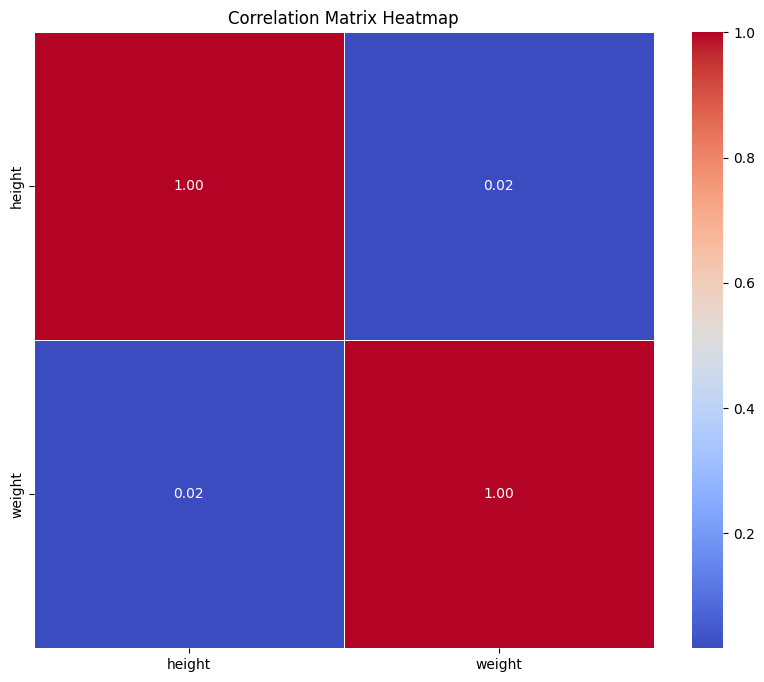

In [20]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")

numeric_columns = participants_df.select_dtypes(include=[np.number]).columns
correlation_matrix = participants_df[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [21]:
categorical_columns = ['gender', 'age_range', 'city', 'country']
numeric_columns = ['height', 'weight']

for cat_col in categorical_columns:
    print(f"\n--- {cat_col} vs numeric variables ---")
    print(participants_df.groupby(cat_col)[numeric_columns].mean())


--- gender vs numeric variables ---
            height     weight
gender                       
f       165.058136  76.108153
m       168.102985  81.132433

--- age_range vs numeric variables ---
               height      weight
age_range                        
18-24      171.065000   69.591750
25-34      165.192609   75.933848
35-44      163.172143   74.395375
45-54      168.066275   80.937980
55-64      169.866667   87.176222
65-74      166.577143  104.520857

--- city vs numeric variables ---
                   height    weight
city                               
Amersfoort         164.00   64.0000
Anaheim            175.05   76.6570
Arlington Heights  170.18   95.2540
Ashburn            175.63   79.4035
Atlanta            168.00   75.9770
...                   ...       ...
Westfield          154.94   47.6730
Weymouth           180.00  110.0000
Wheeling           172.72   74.8430
Yonkers            160.02   78.0180
Zwolle             160.02   61.3710

[117 rows x 2 columns]

---

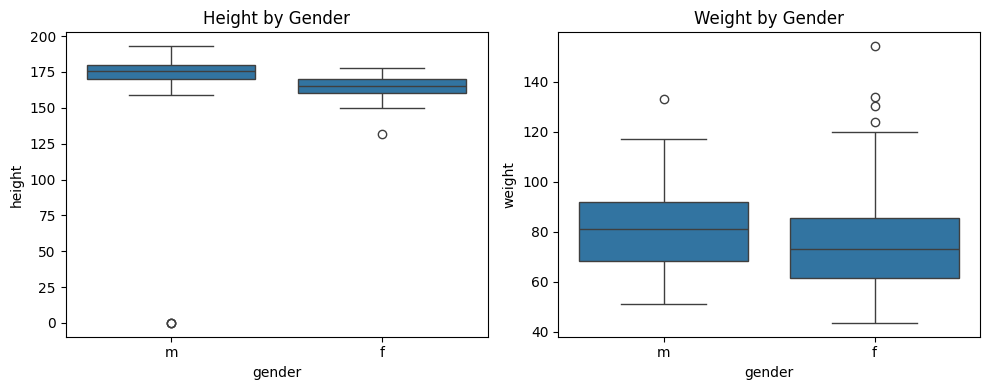

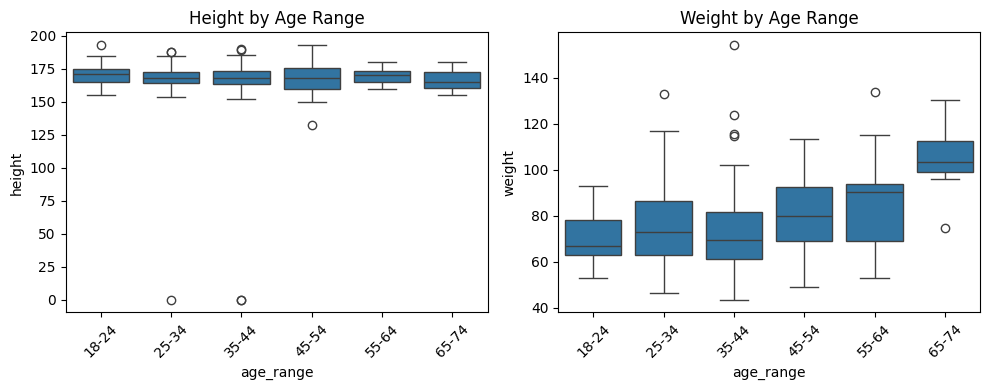

In [22]:
# Box plots — height and weight by gender, side by side in ONE figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=participants_df, x='gender', y='height', ax=axes[0])
axes[0].set_title('Height by Gender')
sns.boxplot(data=participants_df, x='gender', y='weight', ax=axes[1])
axes[1].set_title('Weight by Gender')
plt.tight_layout()
plt.show()

age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=participants_df, x='age_range', y='height', order=age_order, ax=axes[0])
axes[0].set_title('Height by Age Range')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=participants_df, x='age_range', y='weight', order=age_order, ax=axes[1])
axes[1].set_title('Weight by Age Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Interpretation

The Correlation matrix, shows no relation, but the box plots:
- Height by Gender: Males show a higher median height than females, indicating gender is meaningfully related to height
- Weight by Gender: Males also show a higher median weight than females, with females showing more high-end outliers
- Height by Age Range: Medians stay fairly flat across all age brackets, suggesting age_range has little to no relationship with height
- Weight by Age Range: Weight varies more noticeably across age brackets, with 65-74 showing a distinctly higher median, suggesting age_range may have some relationship with weight

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


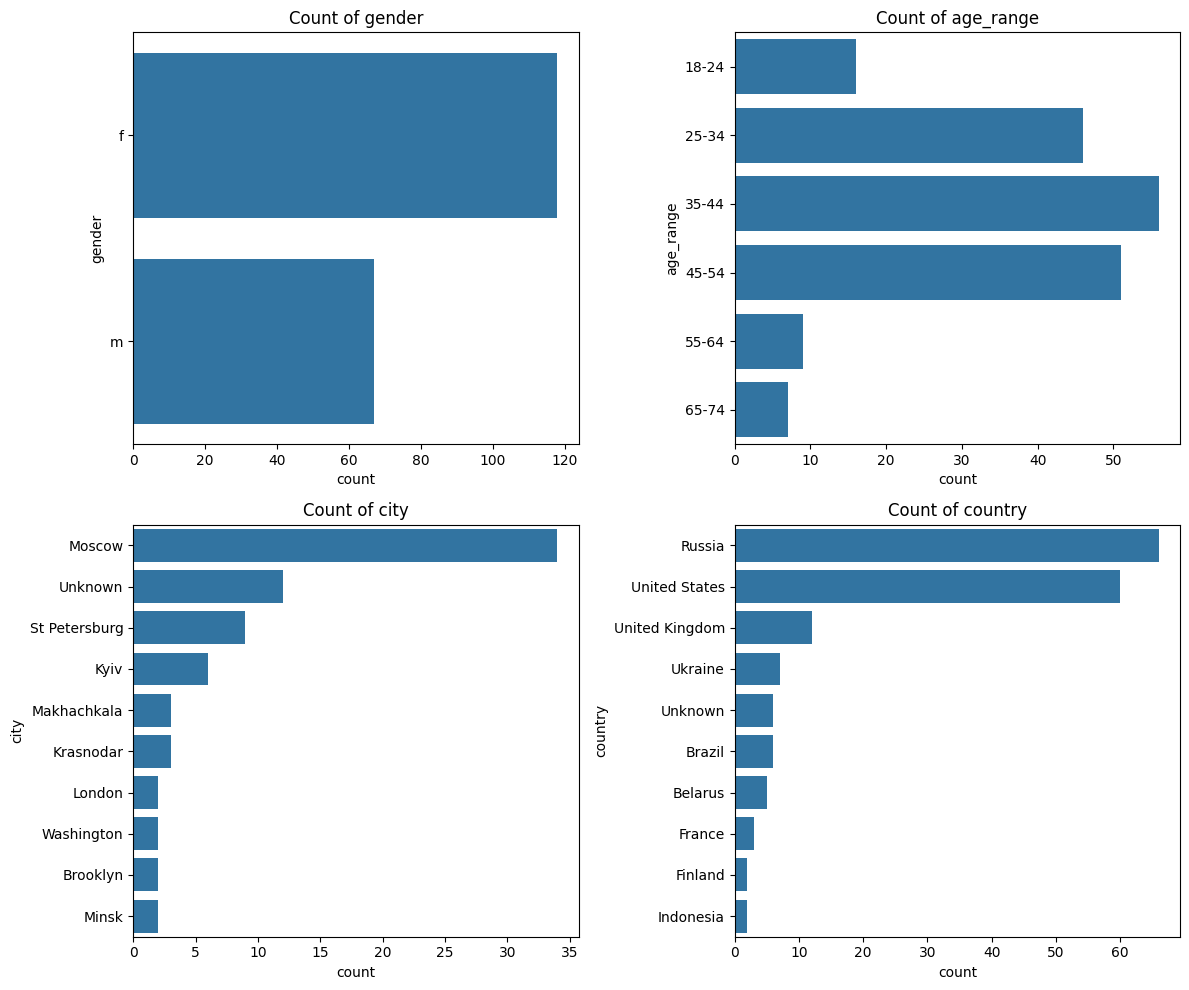

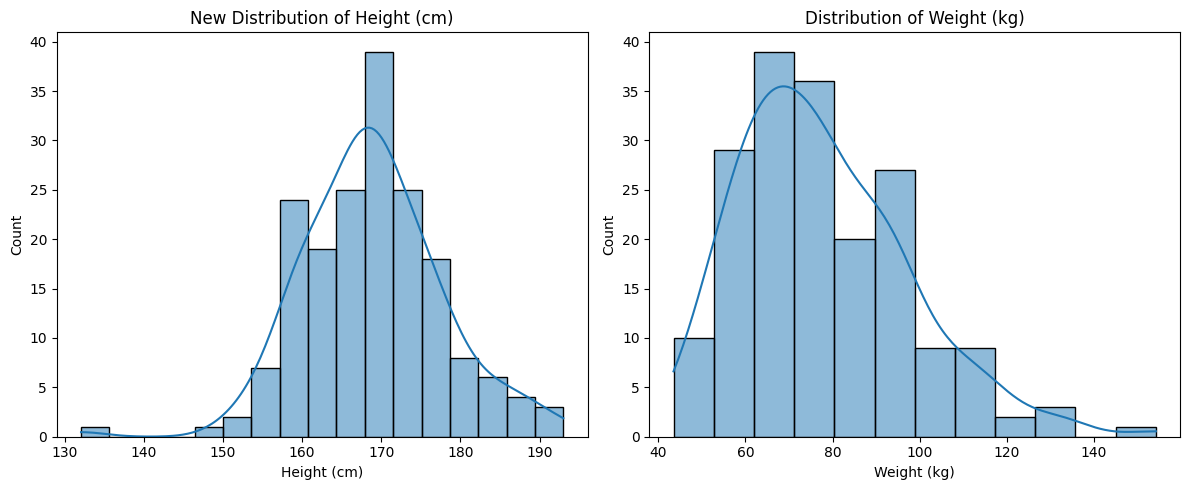

In [23]:
# Categorical columns — bar/count charts
categorical_columns = ['gender', 'age_range', 'city', 'country']
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    if col in ['city', 'country']:
        top_values = participants_df[col].value_counts().nlargest(10).index
        data = participants_df[participants_df[col].isin(top_values)]
        order = top_values
    elif col == 'age_range':
        data = participants_df
        order = age_order
    else:
        data = participants_df
        order = participants_df[col].value_counts().index

    sns.countplot(data=data, y=col, order=order, ax=axes[i])
    axes[i].set_title(f'Count of {col}')

plt.tight_layout()
plt.show()


# Histograms for Height and Weight (excluding the flagged 0 height values)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(participants_df[participants_df['height'] != 0]['height'], kde=True, ax=axes[0])
axes[0].set_title('New Distribution of Height (cm)')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Count')

sns.histplot(participants_df['weight'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Weight (kg)')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Interpretation

#### Bar Plots:
- Count of gender: tells us most of the people in this data are women, they outnumber the men very strongly. 
- Count of age_range: people aged 35--44 were most of the people that are in the data
- Count of Country: Most peope were from Russia, with second palce being the US
- Count of City: Most, to no ones surprise, was also the capital of Russia.

#### Histogram:
- Distrubution of Height: Looks like the skew have been fixed and shows a good deviation(now that we excluded the outliers).
- Distrubution of Weight: shows a right skew still 

## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?



Feature Engineering
-------------------
New Features: Index(['user_code', 'gender', 'age_range', 'city', 'country', 'height',
       'weight', 'bmi', 'bmi_category'],
      dtype='object')


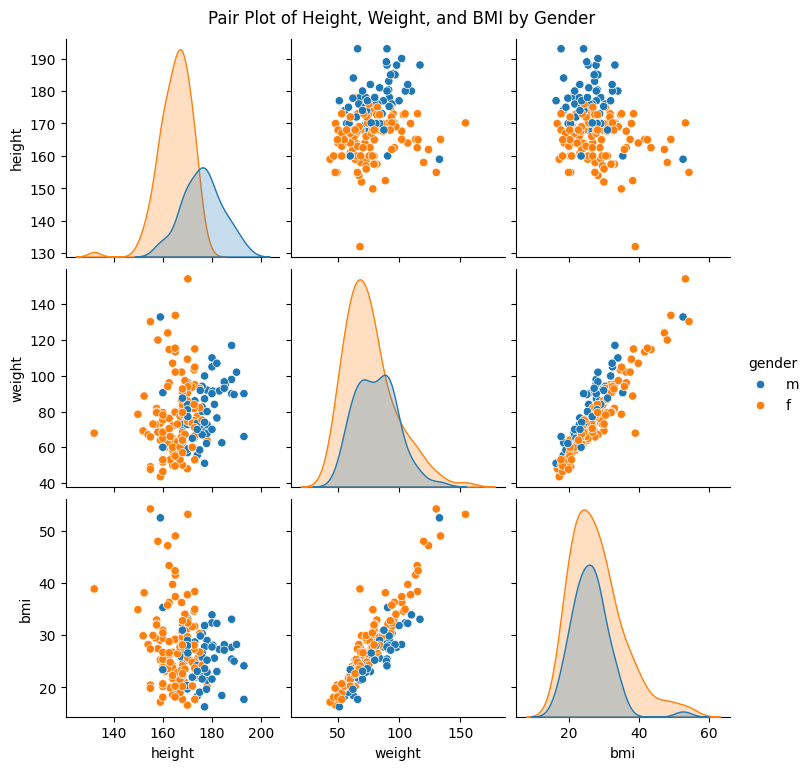

In [24]:
# Feature Engineering
def classify_bmi(bmi):
    if pd.isna(bmi):
        return np.nan
    elif bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal weight'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'


print("\nFeature Engineering")
print("-------------------")
participants_df['height'] = participants_df['height'].replace(0, np.nan)
participants_df['bmi'] = participants_df['weight'] / ((participants_df['height'] / 100) ** 2)
participants_df['bmi_category'] = participants_df['bmi'].apply(classify_bmi)
print(f"New Features: {participants_df.columns}")

sns.pairplot(participants_df, hue='gender', vars=['height', 'weight', 'bmi'])
plt.suptitle('Pair Plot of Height, Weight, and BMI by Gender', y=1.02)
plt.show()

In [25]:
print(participants_df[['bmi', 'bmi_category']].head(10))
print(participants_df['bmi_category'].value_counts())

         bmi   bmi_category
0  33.203698          Obese
1  25.531774     Overweight
2  29.036738     Overweight
3  21.007668  Normal weight
4  27.439513     Overweight
5  27.801717     Overweight
6  20.199470  Normal weight
7  23.913943  Normal weight
8  26.919289     Overweight
9  29.073217     Overweight
bmi_category
Normal weight    66
Overweight       59
Obese            47
Underweight      10
Name: count, dtype: int64


In [26]:
# Apply log transformation to reduce skew in weight
participants_df['weight_log'] = np.log1p(participants_df['weight'])

# Check skew before and after
print("Original weight skew:", participants_df['weight'].skew())
print("Log-transformed weight skew:", participants_df['weight_log'].skew())

print("\nOriginal weight kurtosis:", participants_df['weight'].kurt())
print("Log-transformed weight kurtosis:", participants_df['weight_log'].kurt())

Original weight skew: 0.8653453346400775
Log-transformed weight skew: 0.23088413597223623

Original weight kurtosis: 0.8913683739186298
Log-transformed weight kurtosis: -0.2894406972764272


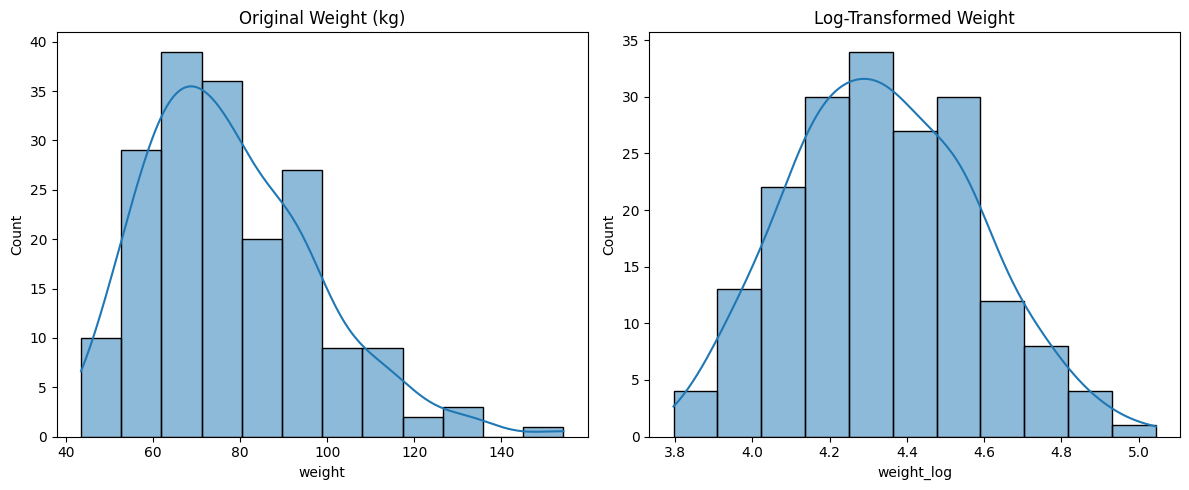

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(participants_df['weight'], kde=True, ax=axes[0])
axes[0].set_title('Original Weight (kg)')

sns.histplot(participants_df['weight_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Weight')

plt.tight_layout()
plt.show()

## Interpretation

#### New Features (BMI and bmi_category):
Created BMI from height and weight since it's a more useful health measure than either alone, and it's often linked to COVID severity. The pair plot shows weight and BMI closely aligned (expected, since BMI comes from weight), while height and weight show little direct relationship. BMI also has a long right tail, meaning a few people have unusually high values. The bmi_category count plots show how many people fall into each weight class, broken down by gender, country, and age range.

#### Transformation (weight_log)
`weight` was right skewed, so I applied a log transformation to pull in the high values without changing the typical ones. Since this skew reflected real data (unlike the height outliers, which were errors we removed), transforming was the better fix than removing anything. After transforming, weight's skew dropped much closer to 0, making the data more balanced. `weight_log` was added a column for viewing purposes.

bmi_category
Normal weight    36.263736
Overweight       32.417582
Obese            25.824176
Underweight       5.494505
Name: proportion, dtype: float64


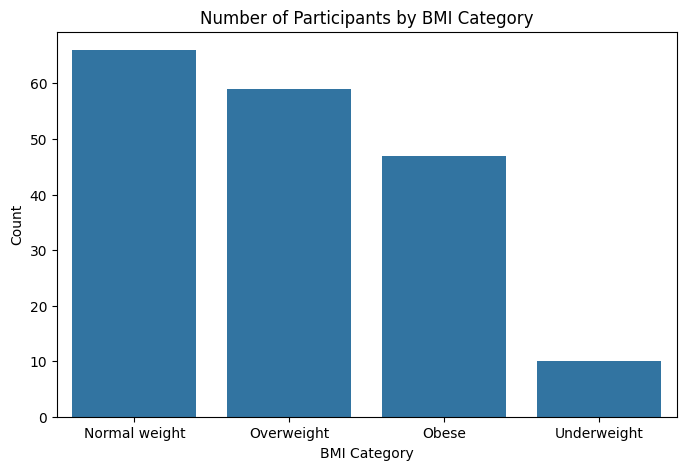

In [28]:
print(participants_df['bmi_category'].value_counts(normalize=True) * 100)
plt.figure(figsize=(8, 5))
order = participants_df['bmi_category'].value_counts().index
sns.countplot(data=participants_df, x='bmi_category', order=order)
plt.title('Number of Participants by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

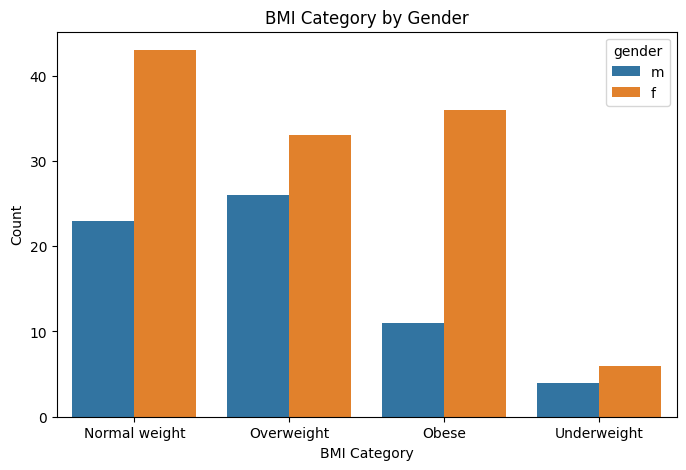

In [29]:
plt.figure(figsize=(8, 5))
order = participants_df['bmi_category'].value_counts().index
sns.countplot(data=participants_df, x='bmi_category', hue='gender', order=order)
plt.title('BMI Category by Gender')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

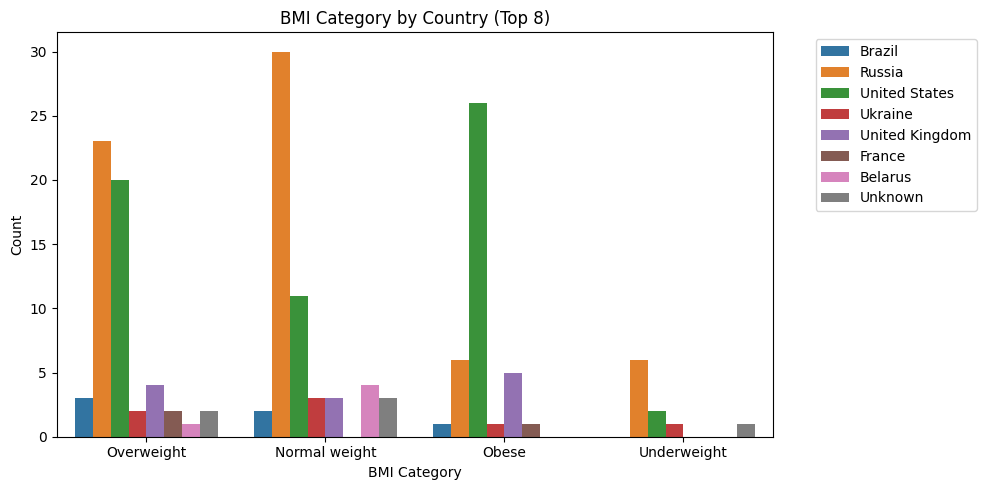

In [30]:
# By country (Top countries only)
top_n = 8
top_countries = participants_df['country'].value_counts().nlargest(top_n).index
df_top_countries = participants_df[participants_df['country'].isin(top_countries)]

order = df_top_countries['bmi_category'].value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(data=df_top_countries, x='bmi_category', hue='country', order=order)
plt.title(f'BMI Category by Country (Top {top_n})')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

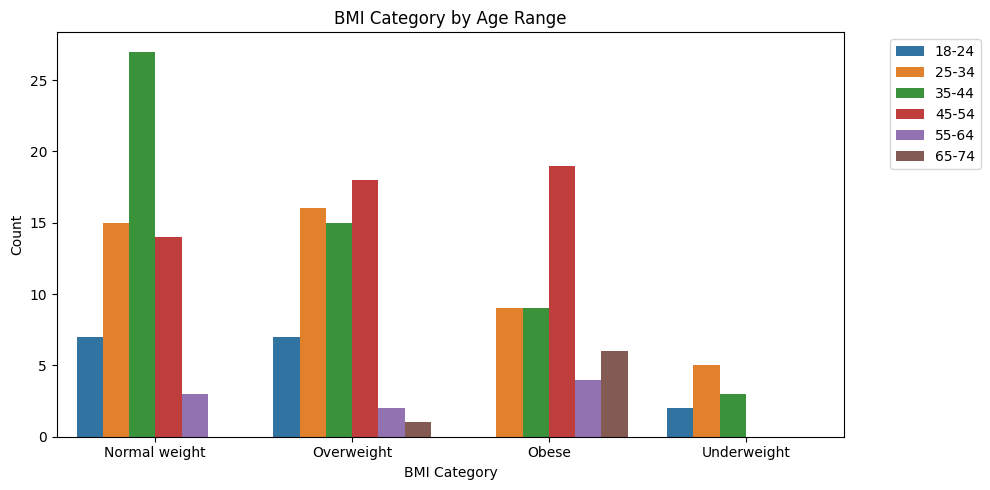

In [31]:
# By age_range
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']

plt.figure(figsize=(10, 5))
sns.countplot(data=participants_df, x='bmi_category', hue='age_range', 
              order=participants_df['bmi_category'].value_counts().index,
              hue_order=age_order)
plt.title('BMI Category by Age Range')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
def simplify_bmi_category(category):
    if pd.isna(category):
        return np.nan
    elif category == 'Normal weight':
        return 'Healthy weight'
    else:
        return 'Unhealthy weight'

participants_df['bmi_category_simple'] = participants_df['bmi_category'].apply(simplify_bmi_category)

print(participants_df['bmi_category_simple'].value_counts())

bmi_category_simple
Unhealthy weight    116
Healthy weight       66
Name: count, dtype: int64


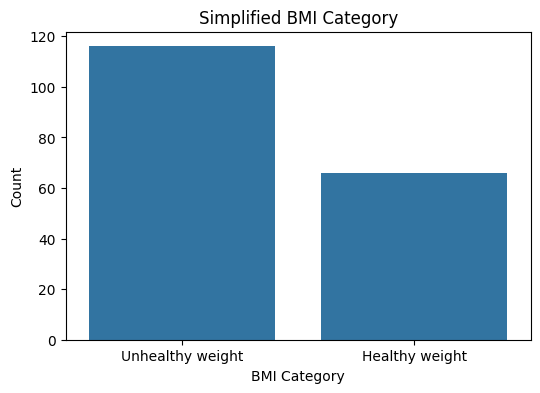

In [33]:
plt.figure(figsize=(6, 4))
order = participants_df['bmi_category_simple'].value_counts().index
sns.countplot(data=participants_df, x='bmi_category_simple', order=order)
plt.title('Simplified BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

#### Another New Feature (bmi_category_simple):
For visual purposes, I added in one more feature based off the `bmi_category` to simply show if someone is a healthy(Normal weight) or unheathy weight(overweight, underweight, obese), to see which most participants fall under. 

In [34]:
# output final dataframe to a CSV
participants_df.to_csv("participants_df.csv", index=False)

## Data Quality

#### Profiling 
The dataset had 185 participants, along side their demographic data.

#### Completeness
Most fields were filled, but there were some missing values in `city`, `country`, `height`, `weight`, and `symptoms_onset`. 

#### Accuracy
Some `height` values I treated as errors and entered them in as unknown/0 instead.

#### Consistency 
All fields in the CSV had a consistent format, except one value in the `user_code` but it did not impact my analysis as `user_code` was not used anywhere. 

#### Integrity 
No duplicaets were found.

#### Lineage and provenance 
Data was taken directly from the Welltory repo(https://github.com/Welltory/hrv-covid19/tree/master)


## Conclusion
This EDA explored the Welltory participant dataset (`participants.csv`), focusing on demographic and physical measurement data (gender, age range, city, country, height, and weight).
We set out to find the people that were affected by covid the most, and what type of characteristics they had. Now keep in mind, these conculsions are only a result of those that participed in the study, and does not reflect the general population that had Covid at the time. 
- Count of gender: Most of the people in this data are women — they outnumber men very strongly.
- Count of age_range: People aged 35–44 make up the largest share of the data.
- Count of country: Most participants were from Russia, with the US in second place.
- Count of city: Most participants were, unsurprisingly, also from the capital of Russia (Moscow).
- Simplified BMI Category: Most people that had covid were also what people/Doctores would consider unhealthy weight(overweight, underweight, obese)

### Other findings:

* Relationships: Gender showed a relationship with height, and a moderate relationship with weight, which was expected considering the biological differences. Age range also showed little relationship with height but some relationship with weight.

* Outliers: There were outliers found in both the height and weight column, which impacted the data and caused a right skew on both graphs. The outliers in the height column were deemed implausiable, and thus were removed, which fixed the data. Then for weight, also extreme values, were deemed plausible, so instead i applied a log transformation to the graph which fixed the deviation and fixed the skew.